In [59]:
# 7-12-2026

In [60]:
# v4- euclidean distance head w bias

In [61]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [62]:
transfer_matrix = pd.read_csv("../transfer-matrix/rf_transfer_matrix.csv")
transfer_matrix.set_index("Unnamed: 0", inplace=True)
transfer_matrix.index.name = None
transfer_matrix.index = transfer_matrix.index.astype(int)
transfer_matrix.columns = transfer_matrix.columns.astype(int)
transfer_matrix

,0,1,2,4,5,6,7,8,11,12,...,32,33,36,37,38,39,45,46,47,49
0,0.392727,0.291660,0.127238,0.058840,0.214817,0.084705,0.149056,0.182358,0.173877,0.026375,...,0.228505,0.243433,0.149609,0.275203,0.112525,-0.011557,0.116862,0.158796,0.025454,0.029928
1,0.142172,0.395760,0.030643,0.010376,0.180707,0.064432,0.056092,0.128808,0.097788,0.039590,...,0.167477,0.032806,0.029704,0.193033,0.055264,0.066550,0.108203,0.199762,0.023240,-0.037710
2,0.196600,0.214445,0.368173,0.023968,0.207323,0.140139,0.172990,0.231019,0.156741,0.057226,...,0.197402,0.223793,0.121457,0.248807,0.134485,0.053503,-0.005610,0.253965,0.031899,0.059566
4,0.235489,0.227173,0.127394,0.410382,0.215954,0.186207,0.125068,0.196603,0.165264,0.034514,...,0.178055,0.245668,0.147579,0.284360,0.217076,-0.003941,0.037643,0.306750,0.137154,0.020968
5,0.190803,0.206530,0.097887,0.087230,0.464604,0.144950,0.159361,0.204884,0.264641,0.104493,...,0.197195,0.232923,0.117228,0.292623,0.170687,-0.020694,0.115293,0.297271,0.067951,0.051770
6,0.178282,0.238235,0.034447,0.220869,0.191487,0.317381,0.118250,0.163631,0.119401,0.021430,...,0.202794,0.247076,0.125801,0.255555,0.201974,-0.068777,0.099243,0.321076,0.102840,-0.017236
7,0.113396,0.054282,0.061550,0.069370,0.044484,0.109329,0.329688,0.092023,0.159883,0.051387,...,0.184071,0.179713,0.142222,0.192045,0.209176,0.035736,0.042035,0.159817,0.008022,0.022467
8,0.181002,0.228547,-0.006209,0.023346,0.133774,0.117255,0.194411,0.424899,0.064289,-0.004919,...,0.093679,0.136592,0.101116,0.173933,0.095452,-0.003312,0.050942,0.240088,0.051530,0.007182
11,0.214508,0.227264,0.109767,0.124790,0.237549,0.076848,0.107019,0.207917,0.551275,-0.003236,...,0.256072,0.166287,0.102690,0.366209,0.181682,-0.007782,0.147501,0.206234,-0.057620,0.064859
12,0.118927,0.175802,-0.016922,0.112255,0.159920,0.070012,0.077276,0.026258,0.103184,0.502334,...,0.163311,-0.091433,0.060118,0.163172,0.119053,0.080449,0.089125,0.118189,0.068853,-0.070408


In [63]:
descriptors = pd.read_csv("../encoder-inputs/domain_descriptions.csv")
descriptors.set_index("domain_id", inplace=True)
descriptors.index = descriptors.index.astype(int)
descriptors.head()

,vpd_mean,vpd_std,vpd_p90,ws10_mean,ws10_std,ws10_p90,t2m_max_mean,t2m_max_std,t2m_max_p90,ndvi_mean,...,swvl4_p90,gwis_ba_mean,gwis_ba_std,gwis_ba_p90,cams_frpfire_mean,cams_frpfire_std,cams_frpfire_p90,fire_sparsity,land_cover_diversity,fire_season_length
domain_id,,,,,,,,,,,,,,,,,,,,,
0,11.229313,5.895861,19.746270,2.516127,1.052111,3.968697,302.43317,4.790887,307.46002,0.641714,...,0.479085,547.38410,1932.2546,1112.03370,0.067789,0.469590,0.097816,0.081824,0.728328,6
1,6.742952,3.144529,10.522034,1.406203,0.511182,2.132592,301.80650,4.735351,305.51370,0.796118,...,0.499585,338.66165,1157.0903,705.89197,0.063071,0.392797,0.108795,0.013560,0.218936,7
2,21.599873,10.565010,36.654785,4.066474,0.951055,5.291819,303.89624,6.380806,311.61792,0.242577,...,0.257699,3360.49340,8181.0723,8625.16300,0.162555,0.925012,0.219152,0.032987,0.602900,7
3,4.211150,2.716757,7.958644,3.166607,1.505368,5.099028,286.08792,10.954839,299.41890,0.550528,...,0.411259,328.76685,739.6544,901.44635,0.041860,0.274789,0.000000,0.001419,0.365885,3
4,2.564834,3.033652,6.938553,3.300411,1.380530,5.114551,273.42078,16.251247,293.80110,0.315671,...,0.447848,669.05206,2307.7700,1315.65490,0.185203,1.571907,0.090595,0.007227,0.615066,5


In [64]:
active_ids = transfer_matrix.index.tolist()
descriptors_active = descriptors.loc[active_ids]

# these are tesintng domains and train domains
holdout_ids = [45, 46, 47, 49]
train_ids = [d for d in active_ids if d not in holdout_ids]

In [65]:
# fit scaler on train descriptors only, transform all 34
scaler = StandardScaler()
train_desc = descriptors_active.loc[train_ids]
scaler.fit(train_desc)

desc_scaled = pd.DataFrame(
    scaler.transform(descriptors_active),
    index=descriptors_active.index,
    columns=descriptors_active.columns
)

In [66]:
atmospheric_cols = ["vpd_mean", "vpd_std", "vpd_p90", "ws10_mean", "ws10_std", "ws10_p90", "t2m_max_mean", "t2m_max_std", "t2m_max_p90", "tp_mean", "tp_std", "tp_p90"]

ground_cols = ["ndvi_mean", "ndvi_std", "ndvi_p90", "swvl1_mean", "swvl1_std", "swvl1_p90", "swvl4_mean", "swvl4_std", "swvl4_p90", "land_cover_diversity"]

fire_cols = ["fwi_mean_mean", "fwi_mean_std", "fwi_mean_p90", "gwis_ba_mean", "gwis_ba_std", "gwis_ba_p90", "cams_frpfire_mean", "cams_frpfire_std", "cams_frpfire_p90", "fire_sparsity", "fire_season_length"]

atmospheric_idx = [desc_scaled.columns.get_loc(c) for c in atmospheric_cols]
ground_idx = [desc_scaled.columns.get_loc(c) for c in ground_cols]
fire_idx = [desc_scaled.columns.get_loc(c) for c in fire_cols]

In [67]:
def make_pairs(id_list, matrix):
    pairs = []
    for i in id_list:
        for j in id_list:
            t_ij = matrix.loc[i, j]
            pairs.append((i, j, t_ij))
    return pairs

train_pairs = make_pairs(train_ids, transfer_matrix)

In [68]:
# test pairs are any pair where at least one domain in holdout
test_pairs = []
for i in active_ids:
    for j in active_ids:
        if i in holdout_ids or j in holdout_ids:
            test_pairs.append((i, j, transfer_matrix.loc[i, j]))

In [69]:
print(f"train pairs: {len(train_pairs)}")  # should be 900
print(f"test pairs: {len(test_pairs)}")    # should be 34*34 - 30*30 = 256

train pairs: 900
test pairs: 256


In [70]:
class TransferDataset(Dataset):
    def __init__(self, pairs, desc_scaled):
        self.pairs = pairs
        self.desc = desc_scaled

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        i, j, t_ij = self.pairs[idx]
        desc_i = torch.tensor(self.desc.loc[i].values, dtype=torch.float32)
        desc_j = torch.tensor(self.desc.loc[j].values, dtype=torch.float32)
        target = torch.tensor(t_ij, dtype=torch.float32)
        return desc_i, desc_j, target

In [71]:
g = torch.Generator()
g.manual_seed(5)

train_dataset = TransferDataset(train_pairs, desc_scaled)
test_dataset = TransferDataset(test_pairs, desc_scaled)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

In [72]:
class ModularEncoder(nn.Module):
    def __init__(self, atmospheric_idx, ground_idx, fire_idx, branch_embed_dim=5, dropout=0.2):
        super().__init__()
        self.atmospheric_idx = atmospheric_idx
        self.ground_idx = ground_idx
        self.fire_idx = fire_idx

        self.atmospheric_branch = self._make_branch(len(atmospheric_idx), branch_embed_dim, dropout)
        self.ground_branch = self._make_branch(len(ground_idx), branch_embed_dim, dropout)
        self.fire_branch = self._make_branch(len(fire_idx), branch_embed_dim, dropout)

    def _make_branch(self, input_dim, embed_dim, dropout): # private
        return nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, embed_dim)
        ) # one branch, now input-16-16-3

    def forward(self, x):
        x_atm = x[:, self.atmospheric_idx]
        x_ground = x[:, self.ground_idx]
        x_fire = x[:, self.fire_idx]

        e_atm = self.atmospheric_branch(x_atm)
        e_ground = self.ground_branch(x_ground)
        e_fire = self.fire_branch(x_fire)

        return torch.cat([e_atm, e_ground, e_fire], dim=-1)

In [73]:
class BiasHead(nn.Module):
    # takes full 33 dim descriptor
    # outputs src bias and tgt bias
    def __init__(self, input_dim=33, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 32),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 16),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(16, 2)
        )

    def forward(self, x):
        out = self.net(x)
        src_bias = out[:, 0]
        tgt_bias = out[:, 1]
        return src_bias, tgt_bias

In [74]:
class TransferModelV4(nn.Module):
    # two independent pathways per domain, no shared weights or inputs
    # head has no learned params, its a fixed formula on cached per domain outputs
    def __init__(self, atmospheric_idx, ground_idx, fire_idx, branch_embed_dim=3):
        super().__init__()
        self.encoder = ModularEncoder(atmospheric_idx, ground_idx, fire_idx, branch_embed_dim)
        self.bias_head = BiasHead(input_dim=33)

    def encode(self, x):
        # run once per domain, gives everything needed for any pair this domain shows up in
        e = self.encoder(x)
        src_bias, tgt_bias = self.bias_head(x)
        return e, src_bias, tgt_bias

    def forward(self, desc_i, desc_j):
        # desc_i plays source role, desc_j plays target role for this pair
        e_i, src_bias_i, _ = self.encode(desc_i)
        e_j, _, tgt_bias_j = self.encode(desc_j)

        dist_sq = ((e_i - e_j) ** 2).sum(dim=-1)
        pred = -dist_sq + src_bias_i + tgt_bias_j
        return pred, src_bias_i, tgt_bias_j

In [75]:
torch.manual_seed(5)
np.random.seed(5)
device = torch.device("cpu")
model = TransferModelV4(atmospheric_idx, ground_idx, fire_idx).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
loss_fn = nn.MSELoss()
NUM_EPOCHS = 250

# l2 reg on bias terms, not applied yet, set to 0 for now
bias_l2_weight = 0.0

# track losses per epoch for plotting later
train_losses = []
test_losses = []

In [76]:
import copy

best_test_loss = float("inf")
best_epoch = -1
best_state = None
patience = 80
epochs_since_improve = 0

for epoch in range(NUM_EPOCHS):
    # training
    model.train()
    train_loss = 0
    train_mae = 0
    for desc_i, desc_j, target in train_loader:
        desc_i, desc_j, target = desc_i.to(device), desc_j.to(device), target.to(device)
        optimizer.zero_grad()
        pred, src_bias_i, tgt_bias_j = model(desc_i, desc_j)
        loss = loss_fn(pred, target)
        # bias l2 penalty, currently zero weight so this is a no op
        bias_penalty = (src_bias_i ** 2).mean() + (tgt_bias_j ** 2).mean()
        loss = loss + bias_l2_weight * bias_penalty
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * len(target)
        train_mae += torch.abs(pred - target).sum().item()
    train_loss /= len(train_dataset)
    train_mae /= len(train_dataset)

    # eval
    model.eval()
    test_loss = 0
    test_mae = 0
    with torch.no_grad():
        for desc_i, desc_j, target in test_loader:
            desc_i, desc_j, target = desc_i.to(device), desc_j.to(device), target.to(device)
            pred, src_bias_i, tgt_bias_j = model(desc_i, desc_j)
            test_loss += loss_fn(pred, target).item() * len(target)
            test_mae += torch.abs(pred - target).sum().item()
    test_loss /= len(test_dataset)
    test_mae /= len(test_dataset)

    # save losses for plotting
    train_losses.append(train_loss)
    test_losses.append(test_loss)

    # track best model by test loss
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        best_epoch = epoch
        best_state = copy.deepcopy(model.state_dict())
        epochs_since_improve = 0
    else:
        epochs_since_improve += 1

    if epoch % 10 == 0:
        print(f"epoch {epoch:>3}, train mse: {train_loss:.4f}, test mse: {test_loss:.4f}, train mae: {train_mae:.4f}, test mae: {test_mae:.4f}")

    if epochs_since_improve >= patience:
        print(f"stopping early at epoch {epoch}, best test mse {best_test_loss:.4f} at epoch {best_epoch}")
        break

# load back the best checkpoint before doing anything downstream
model.load_state_dict(best_state)
print(f"loaded best model from epoch {best_epoch}, test mse {best_test_loss:.4f}")

epoch   0, train mse: 0.0260, test mse: 0.0302, train mae: 0.1297, test mae: 0.1499
epoch  10, train mse: 0.0080, test mse: 0.0136, train mae: 0.0678, test mae: 0.0995
epoch  20, train mse: 0.0073, test mse: 0.0126, train mae: 0.0628, test mae: 0.0941
epoch  30, train mse: 0.0066, test mse: 0.0109, train mae: 0.0591, test mae: 0.0865
epoch  40, train mse: 0.0064, test mse: 0.0105, train mae: 0.0568, test mae: 0.0851
epoch  50, train mse: 0.0064, test mse: 0.0106, train mae: 0.0577, test mae: 0.0851
epoch  60, train mse: 0.0063, test mse: 0.0110, train mae: 0.0568, test mae: 0.0871
epoch  70, train mse: 0.0060, test mse: 0.0104, train mae: 0.0551, test mae: 0.0840
epoch  80, train mse: 0.0057, test mse: 0.0105, train mae: 0.0540, test mae: 0.0847
epoch  90, train mse: 0.0054, test mse: 0.0108, train mae: 0.0536, test mae: 0.0863
epoch 100, train mse: 0.0055, test mse: 0.0103, train mae: 0.0534, test mae: 0.0839
epoch 110, train mse: 0.0056, test mse: 0.0103, train mae: 0.0537, test mae:

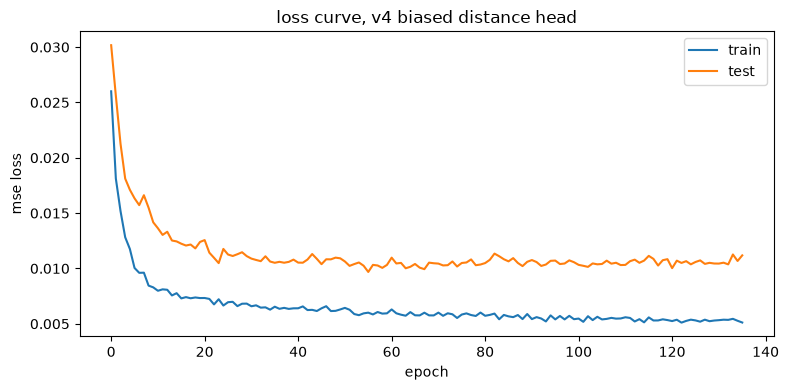

In [77]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="train")
plt.plot(test_losses, label="test")
plt.xlabel("epoch")
plt.ylabel("mse loss")
plt.title("loss curve, v4 biased distance head")
plt.legend()
plt.tight_layout()
plt.show()

In [87]:
torch.save(model.state_dict(), "transfer_model_v4.pt")

In [78]:
# generate all 34x34 pairs
all_pairs = [(i, j) for i in active_ids for j in active_ids]
all_targets = [transfer_matrix.loc[i, j] for i, j in all_pairs]

all_desc_i = torch.tensor(
    np.array([desc_scaled.loc[i].values for i, j in all_pairs]), dtype=torch.float32
).to(device)
all_desc_j = torch.tensor(
    np.array([desc_scaled.loc[j].values for i, j in all_pairs]), dtype=torch.float32
).to(device)
all_targets_tensor = torch.tensor(all_targets, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    all_preds, all_src_bias, all_tgt_bias = model(all_desc_i, all_desc_j)
    all_preds = all_preds.cpu().numpy()
    all_src_bias = all_src_bias.cpu().numpy()
    all_tgt_bias = all_tgt_bias.cpu().numpy()

all_targets_np = np.array(all_targets)

full_mae = np.abs(all_preds - all_targets_np).mean()
full_mse = ((all_preds - all_targets_np) ** 2).mean()
print(f"full matrix mae: {full_mae:.4f}")
print(f"full matrix mse: {full_mse:.4f}")

full matrix mae: 0.0583
full matrix mse: 0.0063


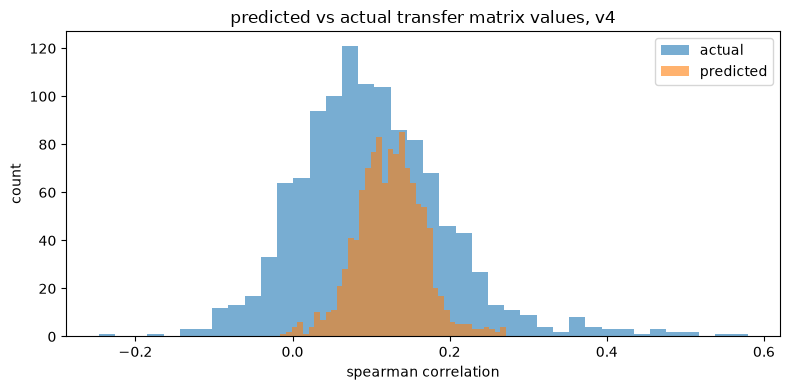

In [79]:
plt.figure(figsize=(8, 4))
plt.hist(all_targets_np, bins=40, alpha=0.6, label="actual")
plt.hist(all_preds, bins=40, alpha=0.6, label="predicted")
plt.xlabel("spearman correlation")
plt.ylabel("count")
plt.title("predicted vs actual transfer matrix values, v4")
plt.legend()
plt.tight_layout()
plt.show()

In [80]:
# get per domain embeddings and biases, once each (not per pair)
domain_desc = torch.tensor(desc_scaled.loc[active_ids].values, dtype=torch.float32).to(device)

In [81]:
model.eval()
with torch.no_grad():
    domain_embeds, domain_src_bias, domain_tgt_bias = model.encode(domain_desc)
    domain_embeds = domain_embeds.cpu().numpy()
    domain_src_bias = domain_src_bias.cpu().numpy()
    domain_tgt_bias = domain_tgt_bias.cpu().numpy()

In [82]:
# embedding spread, low std across domains is a collapse sign
print("embedding dim stds across domains:")
print(domain_embeds.std(axis=0))
print("embedding dim means across domains:")
print(domain_embeds.mean(axis=0))

embedding dim stds across domains:
[0.05850384 0.0521088  0.03511806 0.03415496 0.03746477 0.04240404
 0.05661679 0.06068961 0.04196584]
embedding dim means across domains:
[ 0.05253268 -0.09877352 -0.0630855   0.01075523  0.08199646  0.0413354
 -0.1863622  -0.00388542  0.14245434]


In [83]:
# bias spread, want to compare against embedding contribution below
print(f"src bias std: {domain_src_bias.std():.4f}, tgt bias std: {domain_tgt_bias.std():.4f}")

src bias std: 0.0124, tgt bias std: 0.0283


In [ ]:
dist_terms = []
bias_terms = []
for i, j in all_pairs:
    ei = domain_embeds[active_ids.index(i)]
    ej = domain_embeds[active_ids.index(j)]
    dist_sq = ((ei - ej) ** 2).sum()
    dist_terms.append(-dist_sq)
    bias_terms.append(domain_src_bias[active_ids.index(i)] + domain_tgt_bias[active_ids.index(j)])

dist_terms = np.array(dist_terms)
bias_terms = np.array(bias_terms)

# variance each term contributes to the final prediction
print(f"dist term std: {dist_terms.std():.4f}")
print(f"bias term std: {bias_terms.std():.4f}")
print(f"ratio bias std / dist std: {bias_terms.std() / dist_terms.std():.2f}")

# how much each term alone corelates with actual targets
from scipy.stats import spearmanr
dist_corr, _ = spearmanr(dist_terms, all_targets_np)
bias_corr, _ = spearmanr(bias_terms, all_targets_np)
print(f"dist term alone spearman vs actual: {dist_corr:.4f}")
print(f"bias term alone spearman vs actual: {bias_corr:.4f}")

# this is awesome, both terms basically equallu contributing to final transfer

dist term std: 0.0283
bias term std: 0.0309
ratio bias std / dist std: 1.09
dist term alone spearman vs actual: 0.4778
bias term alone spearman vs actual: 0.4907


In [85]:
pred_matrix = pd.DataFrame(
    all_preds.reshape(34, 34),
    index=active_ids,
    columns=active_ids
)
pred_matrix.shape

(34, 34)

In [ ]:
pred_matrix.to_csv("predicted_transfer_matrix_v4.csv")